# Heterogeneity in Wage Gap

In [1]:
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

In [2]:
# loading the data
file = "https://raw.githubusercontent.com/CausalAIBook/MetricsMLNotebooks/main/data/wage2015_subsample_inference.csv"
df = pd.read_csv(file).drop(columns=['wage'])

df.describe()

,lwage,sex,shs,hsg,scl,clg,ad,mw,so,we,ne,exp1,exp2,exp3,exp4,occ,occ2,ind,ind2
count,5150.000000,5150.000000,5150.000000,5150.000000,5150.000000,5150.000000,5150.000000,5150.000000,5150.000000,5150.000000,5150.000000,5150.000000,5150.000000,5150.000000,5150.000000,5150.000000,5150.000000,5150.000000,5150.000000
mean,2.970787,0.444466,0.023301,0.243883,0.278058,0.317670,0.137087,0.259612,0.296505,0.216117,0.227767,13.760583,3.018925,8.235867,25.118038,5310.737476,11.670874,6629.154951,13.316893
std,0.570385,0.496955,0.150872,0.429465,0.448086,0.465616,0.343973,0.438464,0.456761,0.411635,0.419432,10.609465,4.000904,14.488962,53.530225,11874.356080,6.966684,5333.443992,5.701019
min,1.105912,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10.000000,1.000000,370.000000,2.000000
25%,2.599837,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,0.250000,0.125000,0.062500,1740.000000,5.000000,4880.000000,9.000000
50%,2.956512,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10.000000,1.000000,1.000000,1.000000,4040.000000,13.000000,7370.000000,14.000000
75%,3.324236,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,21.000000,4.410000,9.261000,19.448100,5610.000000,17.000000,8190.000000,18.000000
max,6.270697,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,47.000000,22.090000,103.823000,487.968100,100000.000000,22.000000,100000.000000,22.000000


## Baseline model

In [3]:
baseline = "lwage ~ sex + hsg + scl + clg + (exp1+exp2+exp3+exp4)*(mw+so+we)"
base_model = smf.ols(baseline, data=df[df['shs'] == 0]).fit()  # baseline model with controls, excluding shs as in decomposition
print("The baseline coefficient is: " + str(base_model.params['sex']) +
      " with robust standard error: " + str(base_model.HC3_se['sex']))

The baseline coefficient is: -0.11141189745495836 with robust standard error: 0.01471546953311319


This is the baseline for our heterogeneity analysis. Since the data is quite sparse on different industry/occupation - education combinations, we have to drop these from our analysis compared to the previous notebooks.

## Educational heterogeneity and decomposition

In [4]:
# selecting each major education group (not shs which is only 2.3% of the sample)
edu = ["hsg", "scl", "clg", "ad"]

control = "lwage ~ sex + (exp1+exp2+exp3+exp4)*(mw+so+we)"
model_without_sex = "lwage ~ (exp1+exp2+exp3+exp4)*(mw+so+we)"
# exclude the categorical variables for the decomposition, otherwise the groups 
# may have different numbers of columns in the design matrix

In [5]:
results = []
for e in edu:

    # selecting each education group
    data = df[df[e] == 1].drop(columns=edu).copy()

    # predictive effect of sex
    reg_model = smf.ols(control, data=data).fit()
    control_est = reg_model.params['sex']
    control_se = reg_model.HC3_se['sex']

    # decomposing the gap into explained and unexplained components
    lm0 = smf.ols(model_without_sex, data=data[data["sex"] == 0])
    lm1 = smf.ols(model_without_sex, data=data[data["sex"] == 1])
    XX0 = lm0.exog
    y0 = lm0.endog
    XX1 = lm1.exog
    y1 = lm1.endog

    # the coefficients excluding intercept and "sex"
    betarest = reg_model.params[reg_model.params.index != "sex"][1:]

    marginal_gap = y1.mean() - y0.mean()
    
    diff_unexplained = control_est
    diff_explained = betarest.dot(XX1.mean(0)[1:] - XX0.mean(0)[1:])
    sum_diff = diff_unexplained + diff_explained

    # print(f"{e}: The estimated sex coefficient is {control_est:.4f} "
    #     f"and the corresponding robust standard error is {control_se:.4f}.")
    # print("The marginal gap:", marginal_gap)
    # print("The unexplained difference: ", diff_unexplained)
    # print("The explained difference:", diff_explained)
    # print("The sum of these differences:", sum_diff)

    results.append({
        "edu": e,
        "sex_coef": control_est,
        "sex_se": control_se,
        "N_obs": data.shape[0],
        "marginal_gap": marginal_gap,
        "unexplained": diff_unexplained,
        "explained": diff_explained,
        "sum_diff": sum_diff,
        "significant": "Yes" if abs(control_est) / control_se > 1.96 else "No"
    })

results = pd.DataFrame(results)
results


,edu,sex_coef,sex_se,N_obs,marginal_gap,unexplained,explained,sum_diff,significant
0,hsg,-0.113077,0.028513,1256,-0.118681,-0.113077,-0.005604,-0.118681,Yes
1,scl,-0.118680,0.026939,1432,-0.123464,-0.118680,-0.004784,-0.123464,Yes
2,clg,-0.063670,0.025877,1636,-0.062361,-0.063670,0.001309,-0.062361,Yes
3,ad,-0.160847,0.044229,706,-0.156543,-0.160847,0.004304,-0.156543,Yes


For all education levels, the gap exists and is significant, as shown in the plot below. For the advanced degree level it is largest (-16%), despite the explained diffence being even slightly positive (by controls unexplained difference is even larger than the predictive effect of sex). Here, the controls have different effects depending on educational level (e.g. experience can have different returns for a PhD and a highschool graduate).

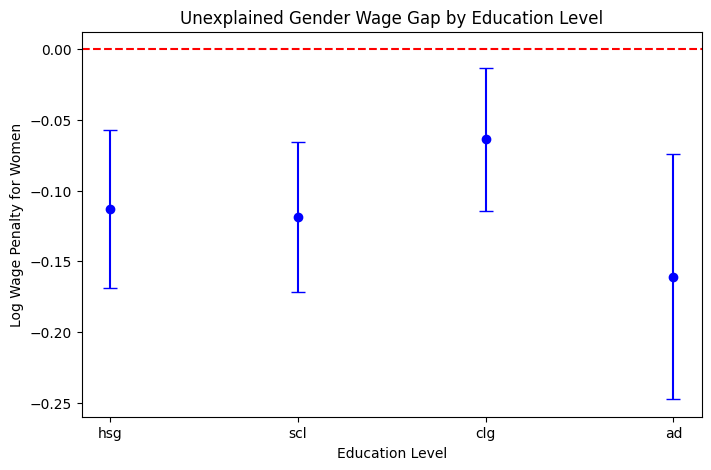

In [6]:
# Calculate 95% Confidence Intervals (1.96 * SE)
results['ci_lower'] = results['sex_coef'] - (1.96 * results['sex_se'])
results['ci_upper'] = results['sex_coef'] + (1.96 * results['sex_se'])

# Plotting the coefficients with error bars
plt.figure(figsize=(8, 5))
plt.errorbar(x=results['edu'], y=results['sex_coef'], 
             yerr=1.96*results['sex_se'], fmt='o', color='b', capsize=5)
plt.axhline(0, color='red', linestyle='--')
plt.title("Unexplained Gender Wage Gap by Education Level")
plt.ylabel("Log Wage Penalty for Women")
plt.xlabel("Education Level")
plt.show()

## Occupational heterogeneity

In [7]:
occ2_values = data['occ2'].unique()
occ2_values

array([ 1,  8, 16, 15,  2,  6,  5, 10, 17,  7,  4,  3, 12,  9, 13, 21, 11,
       19, 22, 14])

In [8]:
# Get unique values of occ2
occ2_values = sorted(data['occ2'].unique())

# Get number of features in the control regression
n_features = len(smf.ols(control, data=data).exog_names) + 1 # +1 for the intercept

# Run control regression for each occ2 category that has both sexes
results_by_occ2 = []

for occ2_val in sorted(occ2_values):
    occ2_data = data[data['occ2'] == occ2_val]
    
    # Check if both sexes are present and each has at least as many rows as number of features
    sex_counts = occ2_data['sex'].value_counts()
    if occ2_data['sex'].nunique() == 2 and all(sex_counts >= n_features):
        reg_model = smf.ols(control, data=occ2_data).fit()
        
        results_by_occ2.append({
            'occ2': occ2_val,
            'sex_coef': reg_model.params['sex'],
            'sex_se': reg_model.HC3_se['sex'],
            'n_obs': len(occ2_data),
            'significant': "Yes" if abs(reg_model.params['sex']) / reg_model.HC3_se['sex'] > 1.96 else "No"
        })

results_occ2 = pd.DataFrame(results_by_occ2)
results_occ2

,occ2,sex_coef,sex_se,n_obs,significant
0,1,-0.067176,0.118244,112,No
1,2,-0.230528,0.166187,56,No
2,7,-0.249848,0.160966,62,No
3,8,-0.052585,0.101762,127,No
4,10,-0.266513,0.138124,90,No


For all occupations for which there is enough data (at least as many rows per sex as features in the model), the predictive effect of sex is negative. However, it is never significant. This is not surprising since we sliced the data in many different groups for each occupation which drastically decreased the sample size which in turn leads to much larger standard errors.

## Conclusion:

To summarize our findings, this analysis demonstrates that the gender wage gap is not a uniform penalty across the labor market, but rather a highly heterogeneous phenomenon. By decomposing the data by education, we uncover major heterogeneities - such as the massive wage penalty for women with advanced degrees — that are completely hidden when looking at a simple, aggregate average.  

Furthermore, while slicing the data by occupation yielded statistically insignificant results due to drastically reduced sample sizes and inflated standard errors, our education decomposition definitively adds to the main takeaway.